# HCPD development accuracy

Evaluation of the correlation between accuracy and age in HCP-D dataset.

In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator, PercentFormatter
from scipy import stats
from scipy.stats import spearmanr
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

project_root = Path('../..').resolve()

from rise import fetch_multi_atlas_label_mapping
prediction_root = project_root / 'models' / 'rise_hcpd_finetune_models'
info_dir = project_root / 'data' / 'HCPD' / 'info'
atlas_mapping_path = fetch_multi_atlas_label_mapping()
figure_dir = project_root / 'analysis' / 'evaluation' / 'figure'
figure_dir.mkdir(parents=True, exist_ok=True)

font_path = project_root / 'font' / 'Whitney-Medium.otf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['svg.fonttype'] = 'none'


## Load atlas metadata, HCPD age information, and prediction groups

In [2]:
# Load the multi-atlas label mapping and basic information for the child cohort.
train_atlas = ['DK', 'AAL', 'HarvardOxford', 'NM', 'BN', 'Glasser', 'Schaefer200', 'Schaefer400']
relabeled_info = pd.read_csv(atlas_mapping_path).reset_index(drop=True)
hcpd_info_children = pd.read_csv(info_dir / 'HCPD_info_children.csv')


# Convert interview age from months to years if age is not already available.
if 'age' not in hcpd_info_children.columns:
    hcpd_info_children['age'] = hcpd_info_children['interview_age'] / 12


# Sort participants by age and split them into groups of 25; the final group may be smaller.
age = hcpd_info_children['age'].to_numpy()
sorted_idx = np.argsort(age)
bin_size = 25
group_idx = [sorted_idx[start:start + bin_size] for start in range(0, len(age), bin_size)]
# Compute the mean age of each group and match it to the Group_i labels in the prediction files.
bin_mean_ages = np.array([age[idx].mean() for idx in group_idx])
test_group_ids = [f'Group_{i}' for i in range(len(group_idx))]


# Find the available repeat_* directories and sort them by repeat number.
repeat_dirs = sorted(prediction_root.glob('repeat_*'), key=lambda path: int(path.name.split('_')[-1]))
repeat_numbers = [int(path.name.split('_')[-1]) for path in repeat_dirs]
if not repeat_numbers:
    raise FileNotFoundError(f'No repeat directories found in {prediction_root}')

print(f'Age groups: {len(test_group_ids)}')


Age groups: 20


## Accuracy by centroid-distance rank

In [3]:
def compute_one_repeat(repeat_n, prediction_root, train_atlas, test_group_ids, relabeled_info, num_bins=10):
    # Load the left- and right-hemisphere predictions for the current repeat.
    pred_path = prediction_root / f'repeat_{repeat_n}' / 'results'
    lh_pred = pd.read_csv(pred_path / 'test_group_pred_parcel_labels_lh.csv')
    rh_pred = pd.read_csv(pred_path / 'test_group_pred_parcel_labels_rh.csv')

    accuracy_by_atlas = []
    for atlas in train_atlas:
        # Divide parcel-to-centroid distances into 10 quantile-based intervals.
        _, bins = pd.qcut(relabeled_info[f'{atlas} Dis'], q=num_bins, retbins=True, duplicates='drop')
        cut_thresh = bins[::-1]
        accuracy_by_group = []

        for group_id in test_group_ids:
            # Select the current age group and concatenate both hemispheres in parcel order.
            lh_group = lh_pred[lh_pred['Subject_ID'] == group_id]
            rh_group = rh_pred[rh_pred['Subject_ID'] == group_id]
            group_preds = pd.concat([lh_group, rh_group], axis=0, ignore_index=True)
            gt_col = f'gt_{atlas}'
            pred_col = f'pred_{atlas}'
            accuracy_by_threshold = []

            # Calculate classification accuracy across progressively stricter distance thresholds.
            for threshold in range(len(cut_thresh) - 1):
                mask = relabeled_info[f'{atlas} Dis'] <= cut_thresh[threshold]
                selected = group_preds.loc[mask]
                accuracy_by_threshold.append((selected[gt_col] == selected[pred_col]).mean() if len(selected) else np.nan)

            accuracy_by_group.append(np.asarray(accuracy_by_threshold))

        accuracy_by_atlas.append(np.asarray(accuracy_by_group))

    return np.asarray(accuracy_by_atlas)


def compute_accuracy_matrix_parallel_repeat(prediction_root, train_atlas, test_group_ids, relabeled_info, repeat_numbers, num_bins=10, n_jobs=4):
    # Repeats are independent and can therefore be processed in parallel.
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(compute_one_repeat)(repeat_n, prediction_root, train_atlas, test_group_ids, relabeled_info, num_bins)
        for repeat_n in repeat_numbers
    )
    return np.asarray(results)


acc_repeat_list = compute_accuracy_matrix_parallel_repeat(
    prediction_root, train_atlas, test_group_ids, relabeled_info,
    repeat_numbers, num_bins=10, n_jobs=min(4, len(repeat_numbers))
)

# Array dimensions: repeat, atlas, age group, and distance threshold.
mean_atlas_acc = np.mean(acc_repeat_list, axis=0)
# Evaluate on the 50% of parcels closest to their respective regional centroids, then average accuracy across repeats while retaining atlas-specific accuracy for each age group.
age_atlas_acc = np.mean(acc_repeat_list[:, :, :, 5], axis=0)

print('acc_repeat_list:', acc_repeat_list.shape)
print('mean_atlas_acc:', mean_atlas_acc.shape)


acc_repeat_list: (10, 8, 20, 10)
mean_atlas_acc: (8, 20, 10)


## Atlas-specific accuracy across age

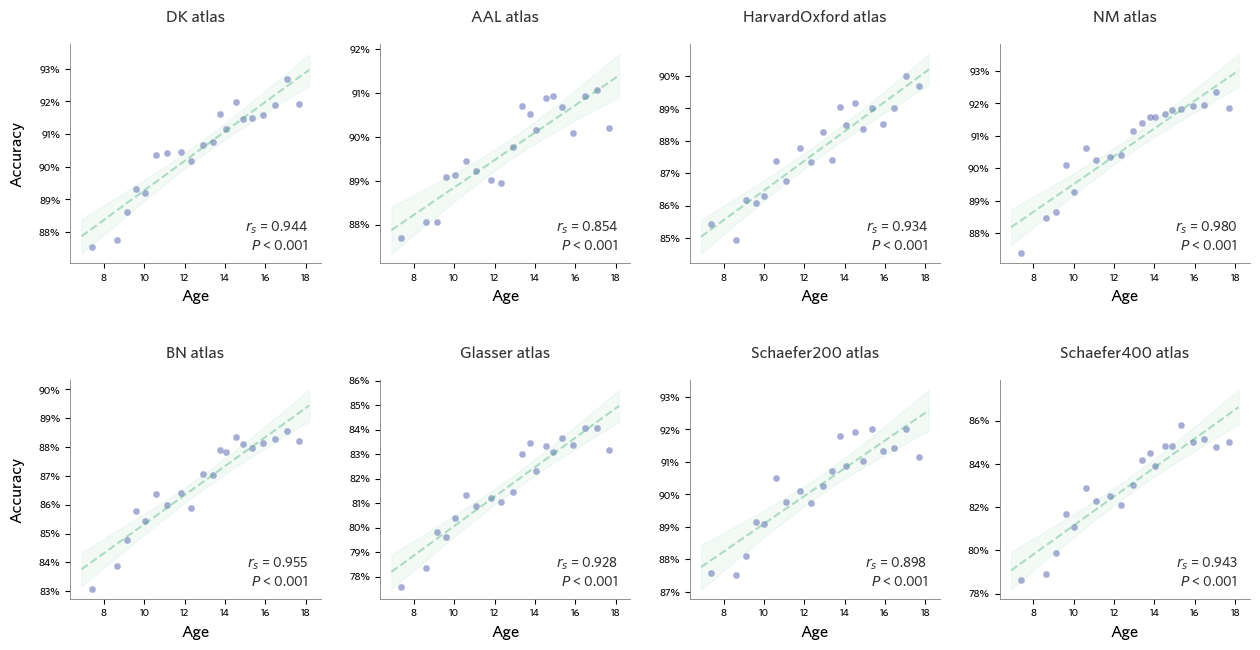

(<Figure size 1270x660 with 8 Axes>,
 array([<Axes: title={'center': 'DK atlas'}, xlabel='Age', ylabel='Accuracy'>,
        <Axes: title={'center': 'AAL atlas'}, xlabel='Age'>,
        <Axes: title={'center': 'HarvardOxford atlas'}, xlabel='Age'>,
        <Axes: title={'center': 'NM atlas'}, xlabel='Age'>,
        <Axes: title={'center': 'BN atlas'}, xlabel='Age', ylabel='Accuracy'>,
        <Axes: title={'center': 'Glasser atlas'}, xlabel='Age'>,
        <Axes: title={'center': 'Schaefer200 atlas'}, xlabel='Age'>,
        <Axes: title={'center': 'Schaefer400 atlas'}, xlabel='Age'>],
       dtype=object))

In [4]:
def plot_atlas_accuracy_grid(x_data, y_data_matrix, atlas_list, x_label='Age', y_label='Accuracy', colors=('#2c7fb8', '#d95f02'), figsize=(12.7, 6.6), line_extend=0.5, save_path=None):
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=figsize)
    axes = axes.flatten()
    dot_color, line_color = colors

    for i, atlas_name in enumerate(atlas_list):
        ax = axes[i]
        y_data = y_data_matrix[i]
        ax.scatter(x_data, y_data, alpha=0.4, edgecolor='w', linewidth=0.4, color=dot_color, s=25)
        # Plot the linear trend and its 95% confidence interval.
        slope, intercept, _, _, _ = stats.linregress(x_data, y_data)
        x_line = np.linspace(x_data.min() - line_extend, x_data.max() + line_extend, 200)
        y_line = slope * x_line + intercept
        n = len(x_data)
        x_mean = np.mean(x_data)
        se = np.sqrt(np.sum((y_data - slope * x_data - intercept) ** 2) / (n - 2))
        ci = stats.t.ppf(0.975, n - 2) * se * np.sqrt(1 / n + (x_line - x_mean) ** 2 / np.sum((x_data - x_mean) ** 2))
        ax.plot(x_line, y_line, color=line_color, linewidth=1.5, linestyle='--', alpha=0.4)
        ax.fill_between(x_line, y_line - ci, y_line + ci, color=line_color, alpha=0.06)
        # Report Spearman correlation with subscript s; r and P are italicized.
        rho, p_value = spearmanr(x_data, y_data)
        p_text = '< 0.001' if p_value < 0.001 else f'= {p_value:.3f}'
        ax.set_title(f'{atlas_name} atlas', fontsize=12, pad=16, color='#333333')
        ax.text(0.95, 0.05, f'$r_s$ = {rho:.3f}\n$P$ {p_text}', transform=ax.transAxes, ha='right', va='bottom', fontsize=10, color='#333333')
        ax.set_xlabel(x_label, fontsize=12, labelpad=5)
        if i % 4 == 0:
            ax.set_ylabel(y_label, fontsize=12, labelpad=10)
        ax.xaxis.set_major_locator(MultipleLocator(2))
        ax.tick_params(axis='both', which='major', labelsize=7.5)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
        ax.grid(False)
        for spine in ('top', 'right'):
            ax.spines[spine].set_visible(False)
        for spine in ('left', 'bottom'):
            ax.spines[spine].set_color('gray')
            ax.spines[spine].set_linewidth(0.6)

    plt.tight_layout(h_pad=3.0, w_pad=2.0)
    plt.show()
    return fig, axes


plot_atlas_accuracy_grid(bin_mean_ages, age_atlas_acc, train_atlas, colors=('#253494', '#41ae76'))
